# Import Library

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Import Dataset

In [20]:
df = pd.read_csv('Dataset/cleaned_order.csv', encoding='utf-8-sig', delimiter=',')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Quarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406824,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,December,4
406825,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,December,4
406826,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,December,4
406827,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,December,4


In [21]:
print(df.dtypes)

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
Revenue        float64
Year             int64
Month            int64
MonthName       object
Quarter          int64
dtype: object


In [22]:
df = df.astype({'CustomerID' : object})
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [23]:
print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
Revenue               float64
Year                    int64
Month                   int64
MonthName              object
Quarter                 int64
dtype: object


# Dataset Overview

In [24]:
print("Total Transactions :", len(df))
print("Unique Customers   :", df["CustomerID"].nunique())
print("Unique Products    :", df["StockCode"].nunique())
print("Countries          :", df["Country"].nunique())

Total Transactions : 406829
Unique Customers   : 4372
Unique Products    : 3684
Countries          : 37


# Revenue Overview

### Total Revenue

In [25]:
total_revenue = round(df["Revenue"].sum(), 2)
print(total_revenue)

8300065.81


### Revenue Per Month

In [26]:
monthly_revenue = (
    df.groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="ME"
        )
    )["Revenue"]
    .sum()
    .reset_index()
)

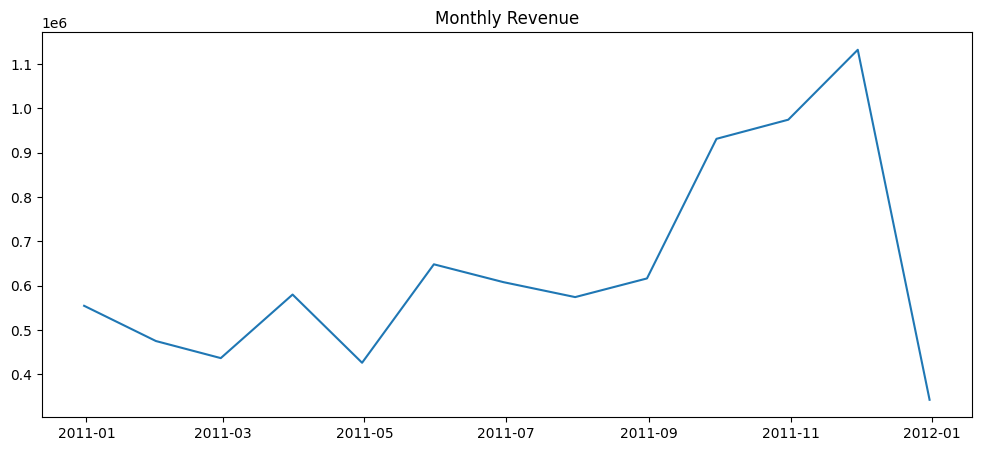

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["InvoiceDate"],
    monthly_revenue["Revenue"]
)

plt.title("Monthly Revenue")
plt.show()

# Revenue Growth

In [28]:
monthly_revenue["GrowthRate"] = (
    monthly_revenue["Revenue"]
    .pct_change()
    * 100
)

In [29]:
monthly_revenue

,InvoiceDate,Revenue,GrowthRate
0,2010-12-31,554604.020,NaN
1,2011-01-31,475074.380,-14.339896
2,2011-02-28,436546.150,-8.109936
3,2011-03-31,579964.610,32.852989
4,2011-04-30,426047.851,-26.538992
5,2011-05-31,648251.080,52.154524
6,2011-06-30,608013.160,-6.207150
7,2011-07-31,574238.481,-5.554926
8,2011-08-31,616368.000,7.336589
9,2011-09-30,931440.372,51.117575


In [30]:
monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

InvoiceDate    2011-11-30 00:00:00
Revenue                 1132407.74
GrowthRate               16.191624
Name: 11, dtype: object

In [31]:
monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

InvoiceDate    2011-12-31 00:00:00
Revenue                  342506.38
GrowthRate              -69.754147
Name: 12, dtype: object

Pertanyaan yang dapat dijawab chatbot:
- Revenue tertinggi kapan?
- Revenue terendah kapan?
- Kapan terjadi pertumbuhan besar?
- Kapan trejadi penurunan besar?

# Product Analysis

### Top Product by Revenue

In [32]:
top_product = (
    df.groupby("Description")
    ["Revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_product = top_product.to_frame()

print(top_product.to_markdown())
print(f"Total Revenue: {round(top_product['Revenue'].sum(),2)}")

| Description                        |   Revenue |
|:-----------------------------------|----------:|
| REGENCY CAKESTAND 3 TIER           |  132870   |
| WHITE HANGING HEART T-LIGHT HOLDER |   93823.9 |
| JUMBO BAG RED RETROSPOT            |   83236.8 |
| PARTY BUNTING                      |   67687.5 |
| POSTAGE                            |   66710.2 |
| ASSORTED COLOUR BIRD ORNAMENT      |   56499.2 |
| RABBIT NIGHT LIGHT                 |   51137.8 |
| CHILLI LIGHTS                      |   45936.8 |
| PAPER CHAIN KIT 50'S CHRISTMAS     |   41500.5 |
| PICNIC BASKET WICKER 60 PIECES     |   39619.5 |
Total Revenue: 679022.59


### Top Product by Quantity

In [33]:
top_qty = (
    df.groupby("Description")
    ["Quantity"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_qty = top_qty.to_frame()

In [34]:
print(top_qty.to_markdown())
print(f"Total Quantity: {top_qty['Quantity'].sum()}")

| Description                        |   Quantity |
|:-----------------------------------|-----------:|
| WORLD WAR 2 GLIDERS ASSTD DESIGNS  |      53215 |
| JUMBO BAG RED RETROSPOT            |      45066 |
| ASSORTED COLOUR BIRD ORNAMENT      |      35314 |
| WHITE HANGING HEART T-LIGHT HOLDER |      34147 |
| PACK OF 72 RETROSPOT CAKE CASES    |      33409 |
| POPCORN HOLDER                     |      30504 |
| RABBIT NIGHT LIGHT                 |      27094 |
| MINI PAINT SET VINTAGE             |      25880 |
| PACK OF 12 LONDON TISSUES          |      25321 |
| PACK OF 60 PINK PAISLEY CAKE CASES |      24163 |
Total Quantity: 334113


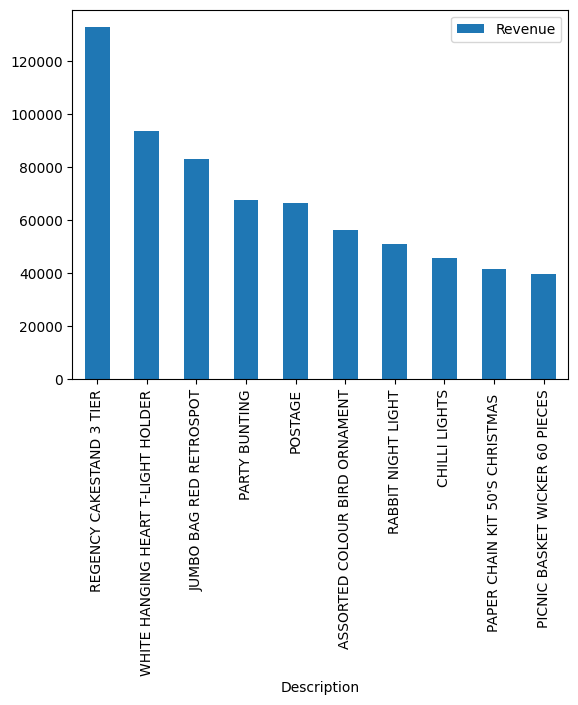

In [35]:
top_product.plot(
    kind="bar"
)
plt.show()

# Customer Analysis

### Top Customer

In [36]:
top_customer = (
    df.groupby("CustomerID")
    ["Revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)
top_customer = top_customer.to_frame()

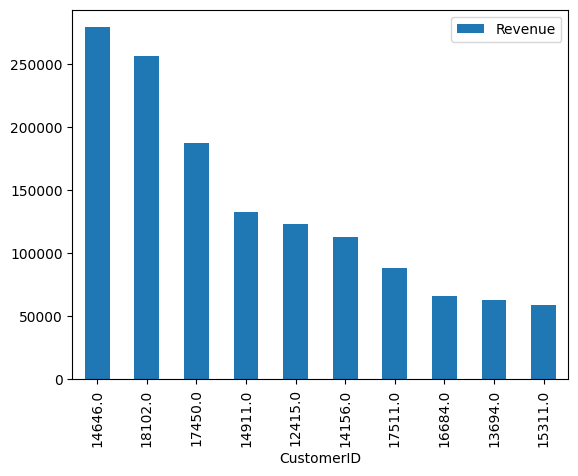

In [37]:
top_customer.plot(
    kind="bar"
)
plt.show()

In [47]:
print(top_customer.to_markdown())
print(f"Total Revenue: {round(top_customer['Revenue'].sum(),2)}")

|   CustomerID |   Revenue |
|-------------:|----------:|
|        14646 |  279489   |
|        18102 |  256438   |
|        17450 |  187482   |
|        14911 |  132573   |
|        12415 |  123725   |
|        14156 |  113384   |
|        17511 |   88125.4 |
|        16684 |   65892.1 |
|        13694 |   62653.1 |
|        15311 |   59419.3 |
Total Revenue: 1369181.79


### Customer Frequency

In [39]:
customer_frequency = (
    df.groupby("CustomerID")
    ["InvoiceNo"]
    .nunique()
)

Pertanyaan yang Dapat Dijawab Chatbot:
- Siapa customer paling loyal?
- Siapa Customer dengan revenue terbesar?

# Country Analysis

### Revenue by Country

In [40]:
country_revenue = (
    df.groupby("Country")
    ["Revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

In [41]:
country_revenue

Country
United Kingdom          6767873.394
Netherlands              284661.540
EIRE                     250285.220
Germany                  221698.210
France                   196712.840
Australia                137077.270
Switzerland               55739.400
Spain                     54774.580
Belgium                   40910.960
Sweden                    36595.910
Japan                     35340.620
Norway                    35163.460
Portugal                  29059.810
Finland                   22326.740
Channel Islands           20086.290
Denmark                   18768.140
Italy                     16890.510
Cyprus                    12946.290
Austria                   10154.320
Singapore                  9120.390
Poland                     7213.140
Israel                     6994.250
Greece                     4710.520
Iceland                    4310.000
Canada                     3666.380
Unspecified                2667.070
Malta                      2505.470
United Arab Emirates

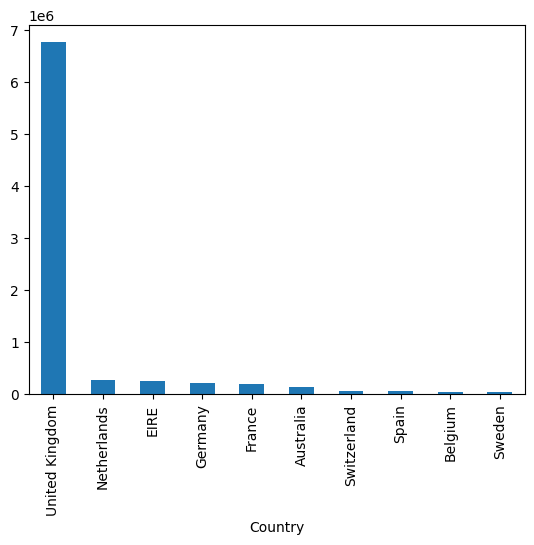

In [42]:
country_revenue.head(10).plot(
    kind="bar"
)

plt.show()

Pertanyaan yang Dapat Dijawab Chatbot:
- Negara mana yang menghasilkan revenue terbesar?
- Negara mana yang performanya menurun?

# Return Analysis


### Persentase Return

In [49]:
return_df = df[
    df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
]

return_rate = (
    round((len(return_df)
    /
    len(df)
    * 100),)
)

print(f"{return_rate}%")

2%


### Produk Paling Sering Di Retur

In [53]:
returned_products = (
    return_df.groupby([
        "StockCode", "Description"]
    )
    ["Quantity"]
    .count()
    .sort_values(
        ascending=False
    )
)
returned_products = returned_products.to_frame()

In [54]:
print(returned_products.to_markdown())
print(f"Total Revenue: {round(returned_products['Quantity'].sum(),2)}")

|                                                   |   Quantity |
|:--------------------------------------------------|-----------:|
| ('22423', 'REGENCY CAKESTAND 3 TIER')             |        181 |
| ('M', 'Manual')                                   |        175 |
| ('POST', 'POSTAGE')                               |         97 |
| ('22960', 'JAM MAKING SET WITH JARS')             |         86 |
| ('D', 'Discount')                                 |         77 |
| ('22720', 'SET OF 3 CAKE TINS PANTRY DESIGN ')    |         73 |
| ('21232', 'STRAWBERRY CERAMIC TRINKET BOX')       |         55 |
| ('22699', 'ROSES REGENCY TEACUP AND SAUCER ')     |         53 |
| ('22666', 'RECIPE BOX PANTRY YELLOW DESIGN')      |         47 |
| ('82483', 'WOOD 2 DRAWER CABINET WHITE FINISH')   |         45 |
| ('85099B', 'JUMBO BAG RED RETROSPOT')             |         44 |
| ('20725', 'LUNCH BAG RED RETROSPOT')              |         42 |
| ('85123A', 'WHITE HANGING HEART T-LIGHT HOLDER')  |         

# Seasonal Analysis

### Revenue Per Bulan

In [45]:
seasonality = (
    df.groupby("Month")
    ["Revenue"]
    .sum()
)

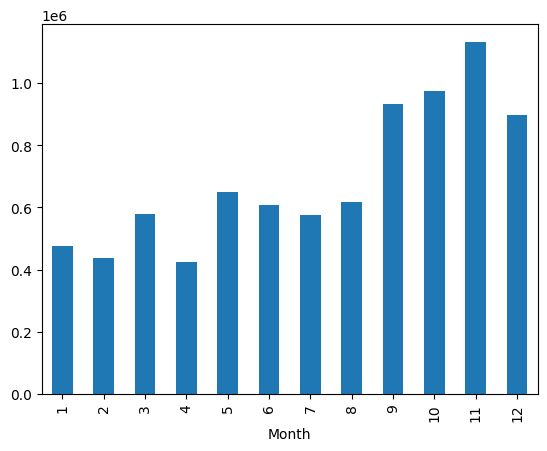

In [46]:
seasonality.plot(
    kind="bar"
)

plt.show()

Pertanyaan yang Dapat Dijawab Chatbot:
- Bulan terbaik
- Bulan terburuk

# Insight Extraction

### 1. Revenue Insight

### Insight 1

Revenue tertinggi terjadi pada bulan November 2011 dengan nilai £1.1 juta, sedangkan revenue terendah terjadi pada bulan Desember 2011 dengan nilai £342 ribu.

### Insight 2

Revenue bulan November 2011 merupakan revenue tertinggi sepanjang periode pengamatan. Nilai tertinggi ini dibangun oleh trend naik sejak bulan Agustus 2011. Semenjak bulan Agustus 2011 hingga November 2011 kenaikannya sebesar 97.2%. 

### Insight 3

Revenue bulan Desember 2011 merupakan revenue terendah sepanjang periode pengamatan. Meskipun terjadi trend naik hingga bulan November 2011, terjadi penurunan yang sangat signifikan hingga -69.75% pada bulan Desember 2011

### 2. Growth Insight

### Insight 1

Pertumbuhan revenue terbesar terjadi pada bulan Mei 2011 dengan kenaikan sebesar 52.15% dibanding bulan sebelumnya.

### Insight 2

Pertumbuhan revenue terendah terjadi pada bulan Desember 2011 dengan penurunan sebesar -69.75%

### 3. Product Insight

### Insight 1

Produk Regency Cakestand 3 Tier memberikan kontribusi revenue terbesar dibanding produk lainnya dengan menyumbang sebesar £133 ribu (0.16%) dari total seluruh pendapatan perusahaan pada periode pengamatan

### 4. Customer Insight

### Insight 1

Customer dengan ID 14646 memberikan kontribusi revenue terbesar selama periode transaksi dengan nilai £279 ribu (0.03%)

### Insight 2

Sepuluh customer teratas menyumbang 16.5% dari total revenue

### 5. Country Insight

### Insight 1

United Kingdom merupakan pasar utama dengan kontribusi £6.7 juta (81.5%) dari total revenue

### Insight 2

Saudi Arabia merupakan negara yang memberikan kontribusi terkecil sebesar £131. Hal ini mengindikasikan bahwa Saudi Arabia bukanlah target pasar kita

### 6. Return Insight

### Insight 1

Produk Regency Cakestand 3 Tier dengan kode barang 22423 dan produk Manual dengan kode barang M merupakan produk yang paling sering diretur dengan jumlah 181 dan 175, sehingga perlu dilakukan evaluasi kualitas atau kesesuaian produk

### 7. Seasonal Insight

Revenue menunjukkan pola musiman dengan peningkatan signifikan pada kuartal keempat, terutama menjelang akhir tahun.